Data Dictionary:
**ARREST_KEY:** Randomly generated persistent ID for each arrest

**ARREST_DATE:** Exact date of arrest for the reported event

**PD_CD:** Three digit internal classification code (more granular than Key Code)

**PD_DESC:** 	Description of internal classification corresponding with PD code (more granular than Offense Description)

**KY_CD**	Three digit internal classification code (more general category than PD code)

**OFNS_DESC**: 	Description of internal classification corresponding with KY code (more general category than PD description)

**LAW_CODE**: Law code charges corresponding to the NYS Penal Law, VTL and other various local laws

**LAW_CAT_CD**: Level of offense: felony, misdemeanor, violation

**ARREST_BORO**:	Borough of arrest. B(Bronx), S(Staten Island), K(Brooklyn), M(Manhattan), Q(Queens)

**ARREST_PRECINCT**:	Precinct where the arrest occurred

**JURISDICTION_CODE**:	Jurisdiction responsible for arrest. Jurisdiction codes 0(Patrol), 1(Transit) and 2(Housing) represent NYPD whilst codes 3 and more represent non NYPD jurisdictions

**AGE_GROUP**:	Perpetrator’s age within a category

**PERP_SEX**:	Perpetrator’s sex description

**PERP_RACE**:	Perpetrator’s race description

**X_COORD_CD**:	Midblock X-coordinate for New York State Plane Coordinate System, Long Island Zone, NAD 83, units feet (FIPS 3104)

**Y_COORD_CD**:	Midblock Y-coordinate for New York State Plane Coordinate System, Long Island Zone, NAD 83, units feet (FIPS 3104)

**Latitude**: Latitude coordinate for Global Coordinate System, WGS 1984, decimal degrees (EPSG 4326)

**Longitude**:	Longitude coordinate for Global Coordinate System, WGS 1984, decimal degrees (EPSG 4326)


In [8]:
# load dataset (from Google Drive) to Colab
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

df = pd.read_csv("https://drive.google.com/uc?id=1OS-1FVLR3P06yZR80i_O46gVn8rYEEZZ")#shared csv file
df.head()

,ARREST_KEY,ARREST_DATE,PD_CD,PD_DESC,KY_CD,OFNS_DESC,LAW_CODE,LAW_CAT_CD,ARREST_BORO,ARREST_PRECINCT,JURISDICTION_CODE,AGE_GROUP,PERP_SEX,PERP_RACE,X_COORD_CD,Y_COORD_CD,Latitude,Longitude,Location
0,299201470,01/10/2025,105,STRANGULATION 1ST,106.0,FELONY ASSAULT,PL 1211200,F,Q,110,0,25-44,F,WHITE,1017105,210917,40.745543,-73.881427,POINT (-73.881427 40.745543)
1,299351927,01/13/2025,105,STRANGULATION 1ST,106.0,FELONY ASSAULT,PL 1211200,F,S,120,0,25-44,M,BLACK,962808,174275,40.645005,-74.077265,POINT (-74.077265 40.645005)
2,299366743,01/13/2025,157,RAPE 1,104.0,RAPE,PL 130351A,F,B,46,0,25-44,M,BLACK HISPANIC,1011755,250279,40.853598,-73.900577,POINT (-73.9005768807295 40.8535983673823)
3,300990163,02/12/2025,153,RAPE 3,104.0,RAPE,PL 1302504,F,K,77,0,(null),(null),BLACK,1003509,185018,40.674496,-73.930571,POINT (-73.9305713255961 40.6744956865259)
4,301010124,02/12/2025,157,RAPE 1,104.0,RAPE,PL 130353A,F,K,77,0,25-44,M,BLACK,1003509,185018,40.674496,-73.930571,POINT (-73.9305713255961 40.6744956865259)


In [9]:
df.info()
# null value: (null)
# 278953 rows, 18 columns,

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 278953 entries, 0 to 278952
Data columns (total 19 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   ARREST_KEY         278953 non-null  int64  
 1   ARREST_DATE        278953 non-null  object 
 2   PD_CD              278953 non-null  int64  
 3   PD_DESC            278953 non-null  object 
 4   KY_CD              278930 non-null  float64
 5   OFNS_DESC          278953 non-null  object 
 6   LAW_CODE           278953 non-null  object 
 7   LAW_CAT_CD         277479 non-null  object 
 8   ARREST_BORO        278953 non-null  object 
 9   ARREST_PRECINCT    278953 non-null  int64  
 10  JURISDICTION_CODE  278953 non-null  int64  
 11  AGE_GROUP          278953 non-null  object 
 12  PERP_SEX           278953 non-null  object 
 13  PERP_RACE          278953 non-null  object 
 14  X_COORD_CD         278953 non-null  int64  
 15  Y_COORD_CD         278953 non-null  int64  
 16  La

In [3]:
#print column names for copy and paste
df.columns

Index(['ARREST_KEY', 'ARREST_DATE', 'PD_CD', 'PD_DESC', 'KY_CD', 'OFNS_DESC',
       'LAW_CODE', 'LAW_CAT_CD', 'ARREST_BORO', 'ARREST_PRECINCT',
       'JURISDICTION_CODE', 'AGE_GROUP', 'PERP_SEX', 'PERP_RACE', 'X_COORD_CD',
       'Y_COORD_CD', 'Latitude', 'Longitude', 'Location'],
      dtype='object')

In [5]:
# unique values of each columns.....
for col in df[['LAW_CODE', 'LAW_CAT_CD', 'ARREST_BORO', 'ARREST_PRECINCT',
       'JURISDICTION_CODE', 'AGE_GROUP', 'PERP_SEX', 'PERP_RACE']]:
    print(f"'>>>'{col}': {df[col].unique()}")

'>>>'LAW_CODE': ['PL 1211200' 'PL 130351A' 'PL 1302504' ... 'PL 2204800' 'PL 1902504'
 'PL 2200909']
'>>>'LAW_CAT_CD': ['F' 'M' nan 'V' '9' 'I']
'>>>'ARREST_BORO': ['Q' 'S' 'B' 'K' 'M']
'>>>'ARREST_PRECINCT': [110 120  46  77  43  40  78  69  52  32  41 116 112  71 113  70  67  75
   6  50   9  23 102  73  24  28  83  48  84  76 103 100 101  42 114  14
  79  81   5  60  19  66 105  30 106  72  20  26  44  94  25  45 121 115
  18  62  49  13 123  47 107 108 109  88  33  34   1  10  61  63  90  68
 122 104  17   7 111  22]
'>>>'JURISDICTION_CODE': [ 0 71  2  1 17  3 72 73 14 51 97  7 13 11  4 52 88 69 12 16 79 74 85 87
 76]
'>>>'AGE_GROUP': ['25-44' '(null)' '45-64' '<18' '18-24' '65+']
'>>>'PERP_SEX': ['F' 'M' '(null)']
'>>>'PERP_RACE': ['WHITE' 'BLACK' 'BLACK HISPANIC' 'WHITE HISPANIC' 'UNKNOWN'
 'ASIAN / PACIFIC ISLANDER' 'AMERICAN INDIAN/ALASKAN NATIVE']


In [13]:
#sum and percentage of missing values before data cleaning
missing_value = ['(null)','nan']

pd.DataFrame({'nan_count': df.isin(missing_value).sum(),
    'nan_%': df.isin(missing_value).mean() * 100})

,nan_count,nan_%
ARREST_KEY,0,0.000000
date,0,0.000000
PD_CD,0,0.000000
pd_description,23,0.008245
KY_CD,0,0.000000
offense_description,23,0.008245
LAW_CODE,0,0.000000
level_of_offense,0,0.000000
borough,0,0.000000
precinct,0,0.000000


In [98]:
#rename columns and save into df1
df1 = df.rename(columns={
    'ARREST_DATE':'arrest_date',
    'PD_DESC': 'pd_description',
    'OFNS_DESC': 'offense_description',
    'LAW_CAT_CD': 'level_of_offense',
    'ARREST_BORO': 'borough',
    'ARREST_PRECINCT': 'precinct',
    'AGE_GROUP':'age_group',
    'PERP_SEX':'gender',
    'PERP_RACE':'race'
})

In [104]:
#rename values
df1['level_of_offense'] = df1['level_of_offense'].replace({
    'F': 'felony',
    'M': 'misdemeanor',
    'V': 'violation',
    '9': 'Inconsistent/Unclassified',
    'I': 'Infraction'
})

In [99]:
#rename values for analysis
df1['borough'] = df1['borough'].replace({
    'Q': 'Queens',
    'S': 'StatenIsland',
    'B': 'Bronx',
    'K': 'Brooklyn',
    'M': 'Manhattan'
})

df1.head()

,ARREST_KEY,arrest_date,PD_CD,pd_description,KY_CD,offense_description,LAW_CODE,level_of_offense,borough,precinct,JURISDICTION_CODE,age_group,gender,race,X_COORD_CD,Y_COORD_CD,Latitude,Longitude,Location
0,299201470,01/10/2025,105,STRANGULATION 1ST,106.0,FELONY ASSAULT,PL 1211200,F,Queens,110,0,25-44,F,WHITE,1017105,210917,40.745543,-73.881427,POINT (-73.881427 40.745543)
1,299351927,01/13/2025,105,STRANGULATION 1ST,106.0,FELONY ASSAULT,PL 1211200,F,StatenIsland,120,0,25-44,M,BLACK,962808,174275,40.645005,-74.077265,POINT (-74.077265 40.645005)
2,299366743,01/13/2025,157,RAPE 1,104.0,RAPE,PL 130351A,F,Bronx,46,0,25-44,M,BLACK HISPANIC,1011755,250279,40.853598,-73.900577,POINT (-73.9005768807295 40.8535983673823)
3,300990163,02/12/2025,153,RAPE 3,104.0,RAPE,PL 1302504,F,Brooklyn,77,0,(null),(null),BLACK,1003509,185018,40.674496,-73.930571,POINT (-73.9305713255961 40.6744956865259)
4,301010124,02/12/2025,157,RAPE 1,104.0,RAPE,PL 130353A,F,Brooklyn,77,0,25-44,M,BLACK,1003509,185018,40.674496,-73.930571,POINT (-73.9305713255961 40.6744956865259)


In [105]:
#replace nan values in dataset ('AGE_GROUP', 'PERP_SEX','level_of_offense')
df1 = df1.replace(['(null)', 'nan'], 'unknown')
df1.head()

,ARREST_KEY,arrest_date,PD_CD,pd_description,KY_CD,offense_description,LAW_CODE,level_of_offense,borough,precinct,JURISDICTION_CODE,age_group,gender,race,X_COORD_CD,Y_COORD_CD,Latitude,Longitude,Location
0,299201470,2025-01-10,105,STRANGULATION 1ST,106.0,FELONY ASSAULT,PL 1211200,felony,Queens,110,0,25-44,F,WHITE,1017105,210917,40.745543,-73.881427,POINT (-73.881427 40.745543)
1,299351927,2025-01-13,105,STRANGULATION 1ST,106.0,FELONY ASSAULT,PL 1211200,felony,StatenIsland,120,0,25-44,M,BLACK,962808,174275,40.645005,-74.077265,POINT (-74.077265 40.645005)
2,299366743,2025-01-13,157,RAPE 1,104.0,RAPE,PL 130351A,felony,Bronx,46,0,25-44,M,BLACK HISPANIC,1011755,250279,40.853598,-73.900577,POINT (-73.9005768807295 40.8535983673823)
3,300990163,2025-02-12,153,RAPE 3,104.0,RAPE,PL 1302504,felony,Brooklyn,77,0,unknown,unknown,BLACK,1003509,185018,40.674496,-73.930571,POINT (-73.9305713255961 40.6744956865259)
4,301010124,2025-02-12,157,RAPE 1,104.0,RAPE,PL 130353A,felony,Brooklyn,77,0,25-44,M,BLACK,1003509,185018,40.674496,-73.930571,POINT (-73.9305713255961 40.6744956865259)


In [101]:
#count of unique values of every column e.g.arrest_key count 278953, no duplicate value
#and then apply describe funtion
#arrest_borough: mean 55790.6 times, min, max and std of number of arrest in 5 boroughs
df1.apply(lambda x: x.value_counts().describe())

,ARREST_KEY,arrest_date,PD_CD,pd_description,KY_CD,offense_description,LAW_CODE,level_of_offense,borough,precinct,JURISDICTION_CODE,age_group,gender,race,X_COORD_CD,Y_COORD_CD,Latitude,Longitude,Location
count,278953.0,365.000000,273.000000,262.000000,73.000000,63.000000,1148.000000,5.000000,5.000000,78.000000,25.000000,6.000000,3.000000,7.000000,29259.000000,30849.000000,37859.000000,37974.000000,39053.000000
mean,1.0,764.254795,1021.805861,1064.706107,3820.958904,4427.825397,242.990418,55495.800000,55790.600000,3576.320513,11158.120000,46492.166667,92984.333333,39850.428571,9.533921,9.042530,7.368208,7.345895,7.142934
std,0.0,151.059639,3276.396678,3362.363160,7042.496796,7851.776207,1475.399733,75743.852914,25943.159085,2024.519314,46851.475144,56311.778915,63701.570909,47694.425352,58.830834,57.271797,51.395738,51.328786,50.593638
min,1.0,304.000000,1.000000,1.000000,1.000000,1.000000,1.000000,206.000000,11707.000000,109.000000,1.000000,2775.000000,22842.000000,954.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,1.0,650.000000,5.000000,5.000000,104.000000,80.500000,2.000000,874.000000,58083.000000,2220.500000,7.000000,8021.000000,65858.000000,8624.000000,1.000000,1.000000,1.000000,1.000000,1.000000
50%,1.0,734.000000,33.000000,32.000000,526.000000,526.000000,6.000000,3994.000000,62833.000000,3010.500000,127.000000,23556.000000,108874.000000,27764.000000,2.000000,2.000000,2.000000,2.000000,2.000000
75%,1.0,883.000000,326.000000,336.500000,4358.000000,4969.000000,36.250000,111419.000000,66448.000000,4476.000000,545.000000,65128.750000,128055.500000,49362.500000,5.000000,5.000000,4.000000,4.000000,4.000000
max,1.0,1199.000000,29405.000000,29405.000000,39728.000000,39728.000000,28812.000000,160986.000000,79882.000000,10364.000000,234357.000000,147237.000000,147237.000000,134262.000000,2083.000000,2081.000000,2081.000000,2081.000000,2081.000000


In [106]:
#summarizes (string/object) columns
df1.describe(include=['object'])
#ARREST_BORO: count → 278953 non-null values/ unique → 5 boroughs/ top → most arrests in Brooklyn/ freq → arrest 79882 times in Brooklyn
#most frequent level of offense - misdemeanor
#AGE_GROUP and PERP_SEX : 147237 null values
#PERP_RACE: 7 races, most arrest BLACK

,pd_description,offense_description,LAW_CODE,level_of_offense,borough,age_group,gender,race,Location
count,278953,278953,278953,277479,278953,278953,278953,278953,278953
unique,262,63,1148,5,5,6,3,7,39053
top,ASSAULT 3,ASSAULT 3 & RELATED OFFENSES,PL 1200001,misdemeanor,Brooklyn,unknown,unknown,BLACK,POINT (-73.9945368920152 40.7535327012632)
freq,29405,39728,28812,160986,79882,147237,147237,134262,2081


Text(0.5, 1.0, 'Number of Arrest by borough')

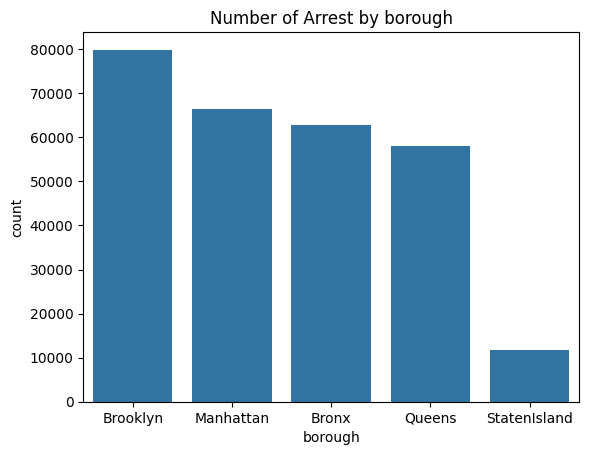

In [18]:
#graph the count of arrest by borough. calculates the specific order of borough names based on their frequency
a = df1['borough'].value_counts().sort_values(ascending=False).index
sns.countplot(x='borough',
              data = df1,
              order=a)
plt.title('Number of Arrest by borough')

In [94]:
#the count of each type of offense in 5 boroughs
df1.groupby(['borough'])['level_of_offense'].value_counts()

borough       level_of_offense         
Bronx         misdemeanor                  37000
              felony                       25077
              violation                      280
              Inconsistent/Unclassified       54
              Infraction                      52
Brooklyn      misdemeanor                  44478
              felony                       32844
              violation                     2251
              Inconsistent/Unclassified       93
              Infraction                      71
Manhattan     misdemeanor                  39573
              felony                       25275
              violation                      691
              Inconsistent/Unclassified      130
              Infraction                      46
Queens        misdemeanor                  32669
              felony                       23839
              violation                      756
              Inconsistent/Unclassified      571
              Infraction                      36
StatenIsland  misdemeanor                   7266
              felony                        4384
              Inconsistent/Unclassified       26
              violation                       16
              Infraction                       1
Name: count, dtype: int64

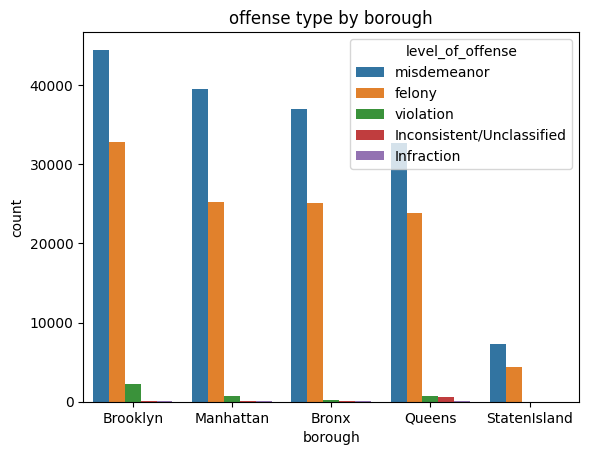

In [112]:
#plot
b = (df1.groupby(['borough','level_of_offense'])
        .size()
        .reset_index(name='count')
        .sort_values('count', ascending=False))

sns.barplot(data=b,
            x='borough',
            y='count',
            hue='level_of_offense')
plt.title('offense type by borough')
plt.show()

Arrest numbers are highest in Brooklyn, followed by Manhattan and the Bronx, and lowest in Staten Island, likely due to its smaller population.
Misdemeanor and felony offenses are the most common types across all boroughs, followed by violations.
Brooklyn records the highest number of both misdemeanors and felonies, while felony counts are relatively similar across the Bronx, Manhattan, and Queens.
These patterns may reflect population differences, and further analysis(age group and race) could provide deeper insight.

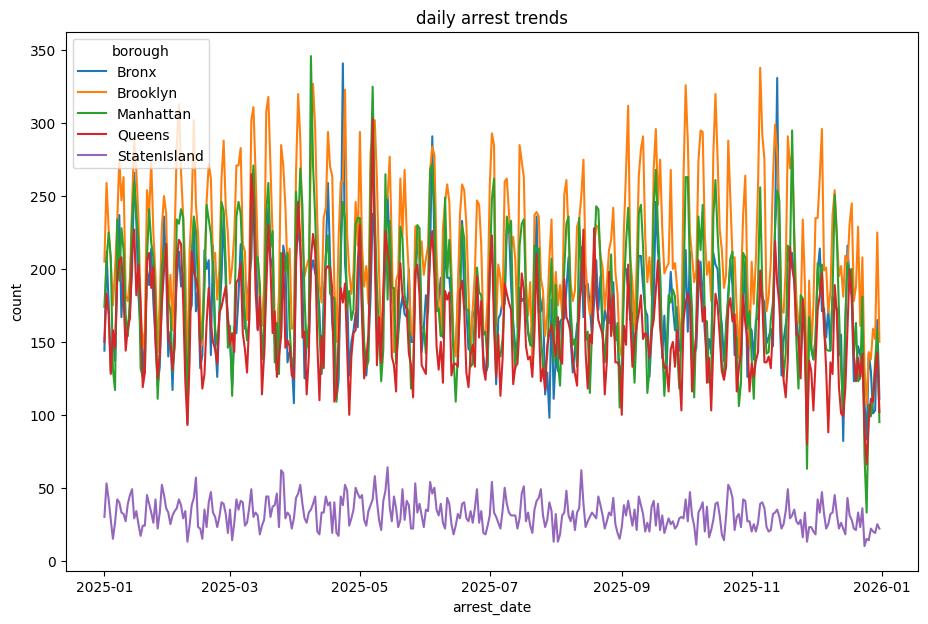

In [130]:
#arrest trend in 5 boroughs daily
df1['arrest_date'] = pd.to_datetime(df1['arrest_date'])
trend = (df1.groupby(['borough','arrest_date'])
              .size()
              .reset_index(name='count'))

plt.figure(figsize=(11, 7))

sns.lineplot(data=trend,
            x='arrest_date',
            y='count',
            hue='borough')

plt.title('daily arrest trends')
plt.show()

Arrest frequency fluctuated throughout the year, with higher levels in late spring, early summer, and autumn, and lower levels observed in Manhattan, Queens, Brooklyn, and the Bronx during the winter months (November to January). It can be concluded that criminal activity is lower during the winter season, and increases as spring begins, suggesting that perpetrators are less active in colder months.